In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import optuna

from drone_dataset import load_data_and_splits, DroneRFDataset
from torch.utils.data import DataLoader

                                          
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Koristimo uređaj: {device}")

                                                                        
                                                                    
                                                                       
data, train_indices, val_indices, test_indices = load_data_and_splits()

print(f"Train: {len(train_indices)}, Val: {len(val_indices)}")

c:\Users\XYZ\Desktop\Tehnologije i alati u mašinskom učenju\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Koristimo uređaj: cuda
Train: 69093, Val: 14806


In [5]:
class ConfigurableCNN(nn.Module):
    """
    Ista logika kao BaselineCNN, ali sa PODESIVIM brojem conv slojeva,
    brojem filtera, i dropout rate-om - ovo su hiperparametri koje
    će Optuna pretraživati.
    """

    def __init__(self, num_conv_layers=3, base_filters=16, dropout_rate=0.3, num_classes=7):
        super().__init__()

                                                                               
                                                                           
                                                                      
        self.conv_layers = nn.ModuleList()

        in_channels = 2                       
        current_filters = base_filters

        for i in range(num_conv_layers):
            self.conv_layers.append(
                nn.Conv2d(in_channels, current_filters, kernel_size=3, padding=1)
            )
            in_channels = current_filters
            current_filters = current_filters * 2                                           

        self.relu = nn.ReLU()                                                                                                                                           
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)                                                                            

                                                               
                                                                                       
        final_spatial_size = 128 // (2 ** num_conv_layers)

                                                                
        flattened_size = in_channels * final_spatial_size * final_spatial_size

        self.flatten = nn.Flatten()                                                                    
        self.fc1 = nn.Linear(flattened_size, 128)                                                                                       
        self.dropout = nn.Dropout(dropout_rate)                                                                           
        self.fc2 = nn.Linear(128, num_classes)                                                           

    def forward(self, x):
                                                                                             
        for conv in self.conv_layers:
            x = self.pool(self.relu(conv(x)))

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [6]:
from sklearn.metrics import f1_score

def objective(trial):
    """
    Optuna poziva ovu funkciju za SVAKI trial (probu).
    'trial' objekat nam daje predložene vrednosti hiperparametara,
    a mi vraćamo BROJ (macro F1) koji Optuna pokušava da MAKSIMIZUJE.
    """

                                                                     
                                     
    num_conv_layers = trial.suggest_int('num_conv_layers', 2, 4)

                                                             
    base_filters = trial.suggest_categorical('base_filters', [8, 16, 32])
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

                                             
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)

                                                                                     
                                                                               
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

                                                                
    train_dataset = DroneRFDataset(data, train_indices)
    val_dataset = DroneRFDataset(data, val_indices)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

                                                    
    model = ConfigurableCNN(
        num_conv_layers=num_conv_layers,
        base_filters=base_filters,
        dropout_rate=dropout_rate
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

                                                                   
                                                                      
                                                                          
                                            
    NUM_TRIAL_EPOCHS = 3

    for epoch in range(NUM_TRIAL_EPOCHS):
        model.train()
        for batch_specs, batch_labels in train_loader:
            batch_specs = batch_specs.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()                                                                
            outputs = model(batch_specs)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

                                                                  
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():                                                                      
        for batch_specs, batch_labels in val_loader:
            batch_specs = batch_specs.to(device)
            outputs = model(batch_specs)
            _, predicted = torch.max(outputs, dim=1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_labels.numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')

                                                                          
                                              
    return macro_f1


In [7]:
                                                                         
test_study = optuna.create_study(direction='maximize')
test_study.optimize(objective, n_trials=2)
print("Test prošao bez grešaka!")

[I 2026-09-10 18:08:45,920] A new study created in memory with name: no-name-a58f59bd-29bb-49e6-b9f0-ea1563c9501f
[I 2026-09-10 18:11:50,968] Trial 0 finished with value: 0.904626064103337 and parameters: {'num_conv_layers': 4, 'base_filters': 32, 'batch_size': 32, 'dropout_rate': 0.1231967962635891, 'learning_rate': 0.0006895797243794356}. Best is trial 0 with value: 0.904626064103337.
[I 2026-09-10 18:13:16,978] Trial 1 finished with value: 0.8790822989059351 and parameters: {'num_conv_layers': 4, 'base_filters': 16, 'batch_size': 32, 'dropout_rate': 0.19729148963701004, 'learning_rate': 0.00044232869085470935}. Best is trial 0 with value: 0.904626064103337.


Test prošao bez grešaka!


In [8]:
study = optuna.create_study(direction='maximize', study_name='drone_rf_automl')
study.optimize(objective, n_trials=20, timeout=3600)

print(f"\nNajbolji trial: {study.best_trial.number}")
print(f"Najbolji macro F1: {study.best_value:.4f}")
print(f"Najbolji hiperparametri: {study.best_params}")

[I 2026-09-10 18:18:43,817] A new study created in memory with name: drone_rf_automl
[I 2026-09-10 18:19:23,949] Trial 0 finished with value: 0.7706441731150083 and parameters: {'num_conv_layers': 2, 'base_filters': 8, 'batch_size': 64, 'dropout_rate': 0.22118794169932682, 'learning_rate': 0.0002456513019401719}. Best is trial 0 with value: 0.7706441731150083.
[I 2026-09-10 18:21:49,364] Trial 1 finished with value: 0.8396792569046152 and parameters: {'num_conv_layers': 2, 'base_filters': 32, 'batch_size': 32, 'dropout_rate': 0.14882488482641731, 'learning_rate': 0.00011254057985924701}. Best is trial 1 with value: 0.8396792569046152.
[I 2026-09-10 18:24:27,822] Trial 2 finished with value: 0.8634269999108719 and parameters: {'num_conv_layers': 3, 'base_filters': 32, 'batch_size': 32, 'dropout_rate': 0.1394731362168248, 'learning_rate': 0.001573496113414252}. Best is trial 2 with value: 0.8634269999108719.
[I 2026-09-10 18:26:48,137] Trial 3 finished with value: 0.8205889178630875 and 


Najbolji trial: 16
Najbolji macro F1: 0.9016
Najbolji hiperparametri: {'num_conv_layers': 4, 'base_filters': 32, 'batch_size': 32, 'dropout_rate': 0.22197109800841963, 'learning_rate': 0.0007171452785079131}


In [9]:
                                                           
best_params = study.best_params
print("Koristimo hiperparametre:", best_params)

                                              
train_dataset = DroneRFDataset(data, train_indices)
val_dataset = DroneRFDataset(data, val_indices)

final_train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
final_val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False)

                                                             
final_model = ConfigurableCNN(
    num_conv_layers=best_params['num_conv_layers'],
    base_filters=best_params['base_filters'],
    dropout_rate=best_params['dropout_rate']
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'])

NUM_EPOCHS = 10                                     

                                                   
automl_train_losses = []
automl_train_accuracies = []
automl_val_losses = []
automl_val_accuracies = []

for epoch in range(NUM_EPOCHS):
                          
    final_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_specs, batch_labels in final_train_loader:
        batch_specs = batch_specs.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = final_model(batch_specs)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_specs.size(0)
        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == batch_labels).sum().item()
        total += batch_labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    automl_train_losses.append(epoch_train_loss)
    automl_train_accuracies.append(epoch_train_acc)

                              
    final_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_specs, batch_labels in final_val_loader:
            batch_specs = batch_specs.to(device)
            batch_labels = batch_labels.to(device)

            outputs = final_model(batch_specs)
            loss = criterion(outputs, batch_labels)

            val_running_loss += loss.item() * batch_specs.size(0)
            _, predicted = torch.max(outputs, dim=1)
            val_correct += (predicted == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total
    automl_val_losses.append(epoch_val_loss)
    automl_val_accuracies.append(epoch_val_acc)

    print(f"Epoha {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

Koristimo hiperparametre: {'num_conv_layers': 4, 'base_filters': 32, 'batch_size': 32, 'dropout_rate': 0.22197109800841963, 'learning_rate': 0.0007171452785079131}
Epoha 1/10 | Train Loss: 0.6431, Train Acc: 0.8111 | Val Loss: 0.4205, Val Acc: 0.8912
Epoha 2/10 | Train Loss: 0.3517, Train Acc: 0.9057 | Val Loss: 0.3044, Val Acc: 0.9179
Epoha 3/10 | Train Loss: 0.2859, Train Acc: 0.9218 | Val Loss: 0.2915, Val Acc: 0.9206
Epoha 4/10 | Train Loss: 0.2529, Train Acc: 0.9304 | Val Loss: 0.2804, Val Acc: 0.9290
Epoha 5/10 | Train Loss: 0.2195, Train Acc: 0.9389 | Val Loss: 0.2576, Val Acc: 0.9375
Epoha 6/10 | Train Loss: 0.1932, Train Acc: 0.9449 | Val Loss: 0.2522, Val Acc: 0.9326
Epoha 7/10 | Train Loss: 0.1692, Train Acc: 0.9497 | Val Loss: 0.2591, Val Acc: 0.9333
Epoha 8/10 | Train Loss: 0.1422, Train Acc: 0.9571 | Val Loss: 0.3326, Val Acc: 0.9329
Epoha 9/10 | Train Loss: 0.1225, Train Acc: 0.9621 | Val Loss: 0.2861, Val Acc: 0.9337
Epoha 10/10 | Train Loss: 0.1097, Train Acc: 0.9668 |

In [10]:
from train_utils import train_with_early_stopping

                                                                            
torch.manual_seed(SEED)

best_params = study.best_params
print("Koristimo hiperparametre:", best_params)

                                              
train_dataset = DroneRFDataset(data, train_indices)
val_dataset = DroneRFDataset(data, val_indices)

final_train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
final_val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False)

                                                             
final_model = ConfigurableCNN(
    num_conv_layers=best_params['num_conv_layers'],
    base_filters=best_params['base_filters'],
    dropout_rate=best_params['dropout_rate']
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'])

                                                                                  
history_automl, best_model_state_automl = train_with_early_stopping(
    model=final_model,
    train_loader=final_train_loader,
    val_loader=final_val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    max_epochs=60,
    patience=10
)

                                   
final_model.load_state_dict(best_model_state_automl)
final_model = final_model.to(device)

print("\nNajbolje težine (AutoML model) učitane.")

Koristimo hiperparametre: {'num_conv_layers': 4, 'base_filters': 32, 'batch_size': 32, 'dropout_rate': 0.22197109800841963, 'learning_rate': 0.0007171452785079131}
Epoha 1/60 | Train Loss: 0.5422, Train Acc: 0.8469 | Val Loss: 0.3679, Val Acc: 0.9071 <- NOVI NAJBOLJI
Epoha 2/60 | Train Loss: 0.3040, Train Acc: 0.9214 | Val Loss: 0.2609, Val Acc: 0.9348 <- NOVI NAJBOLJI
Epoha 3/60 | Train Loss: 0.2397, Train Acc: 0.9371 | Val Loss: 0.2568, Val Acc: 0.9380 <- NOVI NAJBOLJI
Epoha 4/60 | Train Loss: 0.2050, Train Acc: 0.9450 | Val Loss: 0.2524, Val Acc: 0.9406 <- NOVI NAJBOLJI
Epoha 5/60 | Train Loss: 0.1693, Train Acc: 0.9519 | Val Loss: 0.2668, Val Acc: 0.9380 (1/10 bez poboljšanja)
Epoha 6/60 | Train Loss: 0.1380, Train Acc: 0.9581 | Val Loss: 0.2713, Val Acc: 0.9450 (2/10 bez poboljšanja)
Epoha 7/60 | Train Loss: 0.1119, Train Acc: 0.9662 | Val Loss: 0.3077, Val Acc: 0.9423 (3/10 bez poboljšanja)
Epoha 8/60 | Train Loss: 0.0842, Train Acc: 0.9733 | Val Loss: 0.3387, Val Acc: 0.9357 (4/

              precision    recall  f1-score   support

         DJI       0.91      0.78      0.84       329
   FutabaT14       0.95      0.83      0.89      1041
    FutabaT7       0.94      0.81      0.87       549
    Graupner       0.98      0.90      0.94       972
       Noise       0.92      0.99      0.95      7883
     Taranis       0.99      0.96      0.97      2482
     Turnigy       0.95      0.84      0.89      1550

    accuracy                           0.94     14806
   macro avg       0.95      0.87      0.91     14806
weighted avg       0.94      0.94      0.94     14806



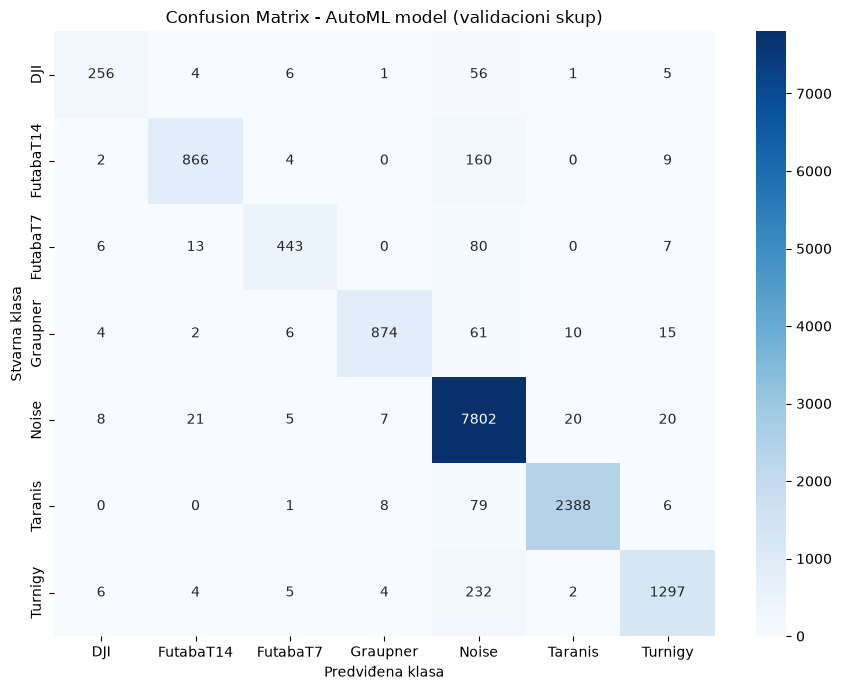

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

final_model.eval()
automl_predictions = []
automl_true_labels = []

with torch.no_grad():
    for batch_specs, batch_labels in final_val_loader:
        batch_specs = batch_specs.to(device)
        outputs = final_model(batch_specs)
        _, predicted = torch.max(outputs, dim=1)
        automl_predictions.extend(predicted.cpu().numpy())
        automl_true_labels.extend(batch_labels.numpy())

class_names_list = ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']

print(classification_report(automl_true_labels, automl_predictions, target_names=class_names_list))

cm_automl = confusion_matrix(automl_true_labels, automl_predictions)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_automl, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_list, yticklabels=class_names_list)
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Confusion Matrix - AutoML model (validacioni skup)')
plt.tight_layout()
plt.savefig('automl_confusion_matrix.png', dpi=150)
plt.show()

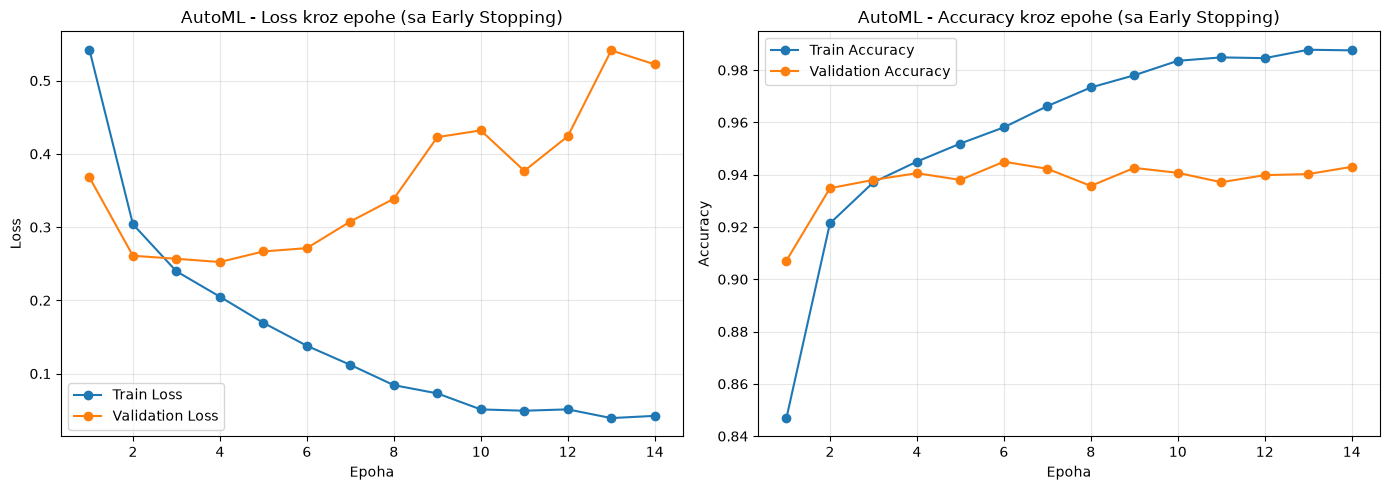

In [13]:
epochs_completed = len(history_automl['train_loss'])
epochs_range = range(1, epochs_completed + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history_automl['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, history_automl['val_loss'], label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].set_title('AutoML - Loss kroz epohe (sa Early Stopping)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_automl['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, history_automl['val_acc'], label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('AutoML - Accuracy kroz epohe (sa Early Stopping)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('automl_training_curves.png', dpi=150)
plt.show()

In [14]:
torch.save(final_model.state_dict(), 'automl_model.pth')

                                                           
                                                                                         
import json
with open('automl_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

print("AutoML model i hiperparametri sačuvani.")

AutoML model i hiperparametri sačuvani.
